# Practica 01 - AAPI  
---
Grupo H: Joaquin Negrete y Pablo Suárez  
2026

Vamos a trabajar con ![River.jpg](./River.jpg)

## Tarea 1
Visualización de la imagen proporcionada para la práctica, separación de los tres canales de color que contiene.

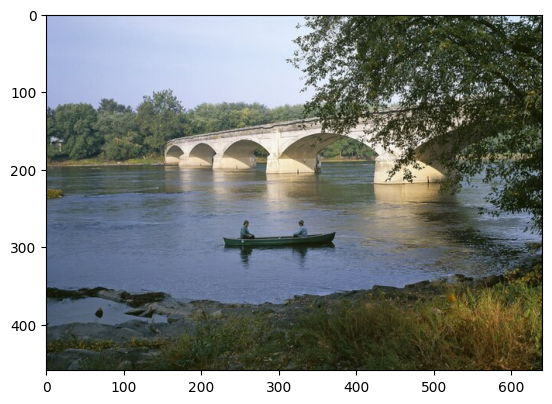

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image

img = Image.open("./River.jpg")
arr = np.array(img)
plt.imshow(img)
plt.show()

Mode: RGB
Size: (640, 459)


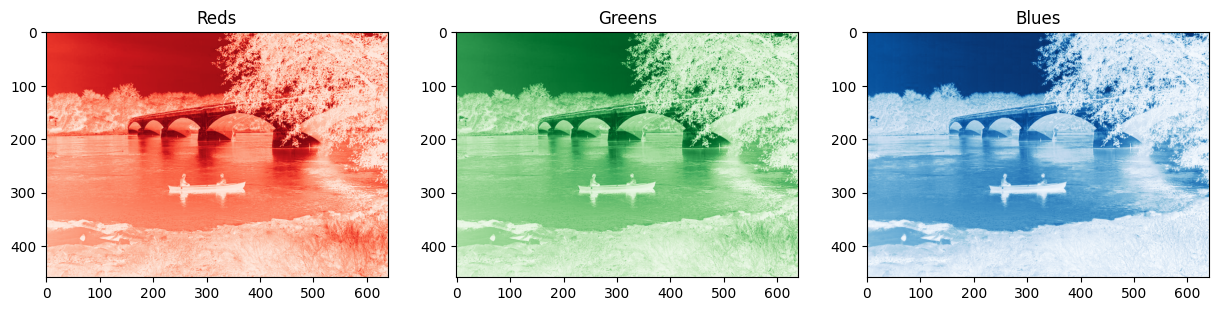

In [5]:
print(f"Mode: {img.mode}")
print(f"Size: {img.size}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names = ["Reds", "Greens", "Blues"]
for i in range(3):
    axes[i].imshow(arr[:,:,i], cmap=names[i])
    axes[i].set_title(names[i])
plt.show()


## Tarea 2
Cálculo de valores estadísticos: media, desviación estándar y varianza de los canales


In [10]:
from math import sqrt

channels = [arr[:,:,i] for i in range(3)]

def img_mean(channel: np.ndarray) -> float:
    cum = 0
    for row in channel:
        cum += np.sum(row)

    return cum / channel.size

def img_variance(channel: np.ndarray) -> float:
    mean = img_mean(channel)
    cum = 0
    for row in channel:
        for el in row:
           cum += (el - mean) ** 2 

    return cum / channel.size

def img_std(channel: np.ndarray) -> float:
    return sqrt(img_variance(channel))

means = [img_mean(channel) for channel in channels]
stds = [img_std(channel) for channel in channels]
variances = [img_variance(channel) for channel in channels]

for i in range(len(channels)):
    print(f"{names[i]} channel - Mean: {means[i]}, Std: {stds[i]}, Variance: {variances[i]}")

Reds channel - Mean: 104.2929091775599, Std: 57.98217458448696, Variance: 3361.9325695459256
Greens channel - Mean: 110.23564474400871, Std: 57.96734531472056, Variance: 3360.213122836056
Blues channel - Mean: 107.35651552287581, Std: 72.97605938124727, Variance: 5325.505242815327


## Tarea 3
Realizar las operaciones aritméticas de suma y resta sobre las bandas que tengan la máxima y la mínima desviación estándard; así como las operaciones lógicas OR y AND.

La máxima es azul y la mínima es verde.  
Para binarizar los canales, como no tenemos un umbral específico, vamos a utilizar la media. 

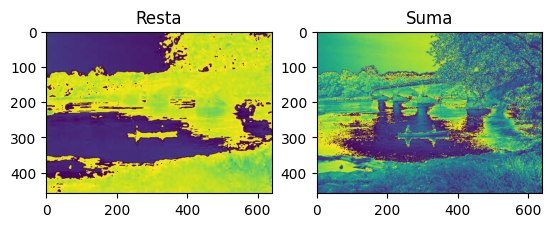

In [11]:
plt.subplot(1, 2, 1)
im_diff = channels[2] - channels[1]
plt.imshow(im_diff)
plt.title("Resta")

plt.subplot(1, 2, 2)
im_sum = channels[2] + channels[1]
plt.imshow(im_sum)
plt.title("Suma")

plt.show()

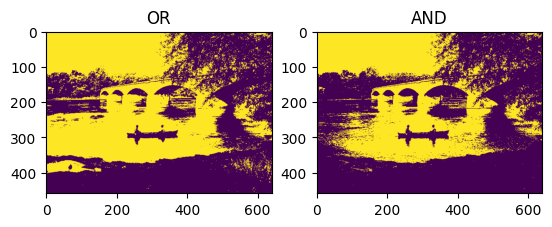

In [12]:
b_bin = (channels[2] > means[2]).astype(np.uint8)
g_bin = (channels[1] > means[1]).astype(np.uint8)

plt.subplot(1, 2, 1)
im_or = b_bin | g_bin
plt.imshow(im_or)
plt.title("OR")

plt.subplot(1, 2, 2)
im_and = b_bin & g_bin
plt.imshow(im_and)
plt.title("AND")

plt.show()

## Tarea 4

Obtener histograma de las bandas originales y con las imágenes de las operaciones aritméticas.

In [ ]:
to_show = {
    "OR": im_or,
    "AND": im_and,
    "resta": im_diff,
    "suma": im_sum,
    "r": channels[0],
    "g": channels[1],
    "b": channels[2]
}